# Inspection of the data: labels and features distributions, correlations, etc.

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

In [2]:
df = pd.read_parquet('./classification_ring/data/processed/train.parquet')


pair_cols = [
    "pdb_id",
    "s_ch", "s_resi", "s_ins", "s_resn",
    "t_ch", "t_resi", "t_ins", "t_resn"
]

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']

#Numerical features
num_features = [
    's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    's_3di_state',
    't_rsa', 't_phi', 't_psi', 't_a1', 't_a2', 't_a3', 't_a4', 't_a5',
    't_3di_state'
]

#Categorical features
cat_features = [
    's_ss8', 's_3di_letter',
    't_ss8', 't_3di_letter'
]



feature_cols = num_features + cat_features

X = df[feature_cols]
Y = df[label_cols]


,label,count,prevalence
6,HBOND,727034,0.727701
5,VDW,506568,0.507033
4,PIPISTACK,26619,0.026643
3,IONIC,24650,0.024673
2,PICATION,6085,0.006091
1,SSBOND,1345,0.001346
0,PIHBOND,1322,0.001323


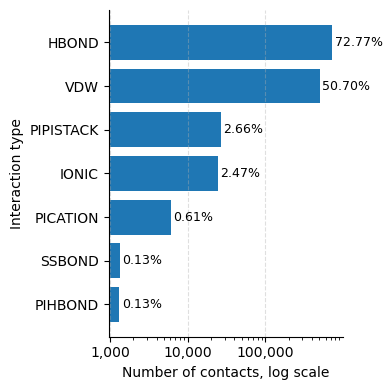

In [15]:


# Count positive examples for each label
label_counts = df[label_cols].sum().sort_values(ascending=True)

# Convert to prevalence
label_prevalence = label_counts / len(df)

label_summary_df = pd.DataFrame({
    "label": label_counts.index,
    "count": label_counts.values,
    "prevalence": label_prevalence.values
}).sort_values("count", ascending=False)

display(label_summary_df)

# Report-quality horizontal bar plot
fig, ax = plt.subplots(figsize=(4, 4))

ax.barh(label_counts.index, label_counts.values)

ax.set_xscale("log")
ax.set_xlabel("Number of contacts, log scale")
ax.set_ylabel("Interaction type")
#ax.set_title("Label counts across interaction types")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}" if x >= 1 else "")
)

ax.grid(axis="x", linestyle="--", alpha=0.4)



# Annotate each bar with prevalence

for label, count in label_counts.items():
    prevalence = label_prevalence.loc[label]
    ax.text(
        count * 1.08,
        label,
        f"{prevalence:.2%}",
        va="center",
        fontsize=9
    )

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
os.makedirs("report_figures", exist_ok=True)
fig.savefig(
    "report_figures/label_frequency.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

--- 
## Labels

**Labels overlap matrix (raw counts):**

In [11]:
# label frequency (fraction of samples with label present)
frequencies = Y.sum(axis =0) / Y.shape[0]
frequencies_df = pd.DataFrame({'label': frequencies.index, 'frequency': frequencies.values})
display(frequencies_df)

,label,frequency
0,HBOND,0.727701
1,VDW,0.507033
2,IONIC,0.024673
3,PIPISTACK,0.026643
4,PICATION,0.006091
5,SSBOND,0.001346
6,PIHBOND,0.001323


In [12]:
overlap_counts = Y.T @ Y

display(overlap_counts)

,HBOND,VDW,IONIC,PIPISTACK,PICATION,SSBOND,PIHBOND
HBOND,727034,249077,22851,7168,1512,46,351
VDW,249077,506568,13150,12666,3219,879,799
IONIC,22851,13150,24650,0,0,0,0
PIPISTACK,7168,12666,0,26619,0,0,295
PICATION,1512,3219,0,0,6085,0,259
SSBOND,46,879,0,0,0,1345,0
PIHBOND,351,799,0,295,259,0,1322


**Label overlap matrix (conditional)**:

Of the samples that have the row label, what fraction also have the column label?

So, for example, the entry (HBOND, VDW) represents the fraction of HBONDs that are also VDW

In [13]:
label_totals = Y.sum(axis=0)

conditional_overlap = overlap_counts.div(label_totals, axis=0)

display(conditional_overlap)

,HBOND,VDW,IONIC,PIPISTACK,PICATION,SSBOND,PIHBOND
HBOND,1.000000,0.342593,0.031430,0.009859,0.002080,0.000063,0.000483
VDW,0.491695,1.000000,0.025959,0.025004,0.006355,0.001735,0.001577
IONIC,0.927018,0.533469,1.000000,0.000000,0.000000,0.000000,0.000000
PIPISTACK,0.269281,0.475826,0.000000,1.000000,0.000000,0.000000,0.011082
PICATION,0.248480,0.529006,0.000000,0.000000,1.000000,0.000000,0.042564
SSBOND,0.034201,0.653532,0.000000,0.000000,0.000000,1.000000,0.000000
PIHBOND,0.265507,0.604387,0.000000,0.223147,0.195915,0.000000,1.000000


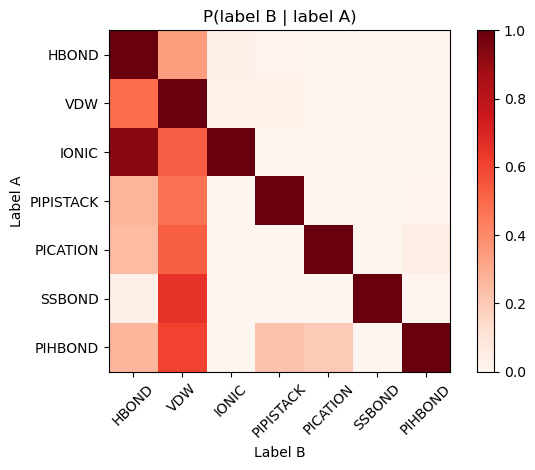

In [14]:
plt.imshow(conditional_overlap, cmap='Reds', vmin=0, vmax=1)
plt.colorbar()
plt.xticks(ticks=np.arange(len(label_cols)), labels=label_cols, rotation=45)
plt.yticks(ticks=np.arange(len(label_cols)), labels=label_cols)
plt.title('P(label B | label A)')
plt.xlabel('Label B')
plt.ylabel('Label A')
plt.tight_layout()
plt.show()

Observations:

- VDW label is very generic: P(VDW | other class label) is $\geq 40\%$ for all the other labels. Roughly half of the samples that receive some label, also receive the VDW label in addition.

- Most of the samples ($\sim 90\%$) labeled as IONIC also get labelled as HBOND. Biologically, this also makes sense. Ionic interactions, or salt bridges, often occur between charged donor/acceptor groups. This means IONIC is highly nested inside HBOND in your labeling scheme. The reverse is much smaller: only about 3.1% of hydrogen bonds are ionic, because many hydrogen bonds are neutral.

- PIPISTACK, PICATION also get assigned in addition to PIHBOND.



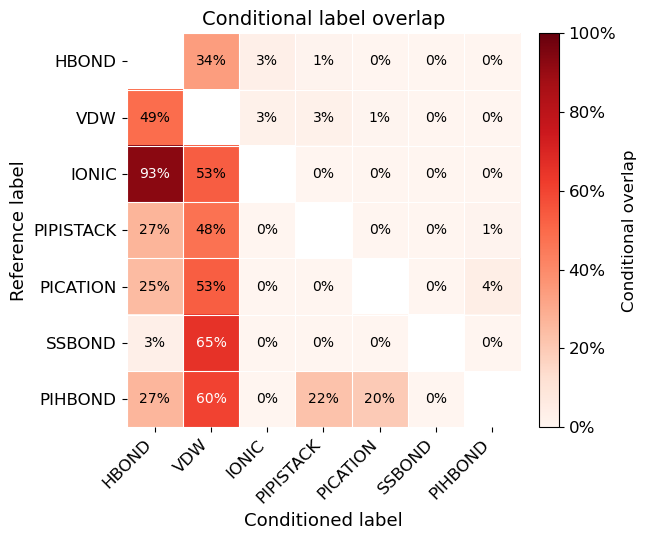

In [20]:
# Font sizes, approximately 20% larger than typical defaults
BASE_SIZE = 12
TITLE_SIZE = 14
LABEL_SIZE = 13
TICK_SIZE = 12
ANNOT_SIZE = 10
CBAR_SIZE = 12

# Ensure row/column order is consistent
plot_matrix = conditional_overlap.loc[label_cols, label_cols].astype(float).copy()

# Mask diagonal, since P(A | A) = 1 by definition
for label in label_cols:
    plot_matrix.loc[label, label] = np.nan

fig, ax = plt.subplots(figsize=(6.5, 5.5))

im = ax.imshow(
    plot_matrix,
    cmap="Reds",
    vmin=0,
    vmax=1
)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Conditional overlap", fontsize=CBAR_SIZE)
cbar.ax.tick_params(labelsize=TICK_SIZE)
cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

ax.set_xticks(np.arange(len(label_cols)))
ax.set_yticks(np.arange(len(label_cols)))
ax.set_xticklabels(label_cols, rotation=45, ha="right", fontsize=TICK_SIZE)
ax.set_yticklabels(label_cols, fontsize=TICK_SIZE)

ax.set_xlabel("Conditioned label", fontsize=LABEL_SIZE)
ax.set_ylabel("Reference label", fontsize=LABEL_SIZE)
ax.set_title("Conditional label overlap", fontsize=TITLE_SIZE)

for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        value = plot_matrix.iloc[i, j]
        if np.isfinite(value):
            ax.text(
                j,
                i,
                f"{value:.0%}",
                ha="center",
                va="center",
                fontsize=ANNOT_SIZE,
                color="black" if value < 0.6 else "white"
            )

ax.set_xticks(np.arange(-0.5, len(label_cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(label_cols), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()

fig.savefig(
    "conditional_label_overlap.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

# Feature distributions: which feature will help discriminate the labels?